In [1]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.layers as layers
import matplotlib.pyplot as plt
import math
from tensorflow.keras.models import Model
from tensorflow.keras.layers import BatchNormalization, Add, UpSampling3D

def global_normalized_cross_correlation_loss():
    def ncc(y_true, y_pred):
        """Computes the normalized cross-correlation (NCC) loss.

        Parameters
        ----------
        y_true : tf.Tensor
            The static image to which the moving image is aligned.
        y_pred : tf.Tensor
            The moving image, the same shape as the static image.

        Returns
        -------
        loss : tf.Tensor, shape ()
            Normalized cross-correlation loss between the static and the
            moving images, averaged over the batch. Range is [-1.0, 1.0].
            The best value is -1 (perfect match) and the worst is 1.

        References
        ----------
        .. [1] `Wikipedia entry for the Cross-correlation
               <https://en.wikipedia.org/wiki/Cross-correlation>`_

        """
        ndim = tf.keras.backend.ndim(y_true)-2

        # shape (N, 1, 1, C)
        y_true_mean = tf.reduce_mean(y_true, axis=range(1, ndim+1),
                                     keepdims=True)
        y_pred_mean = tf.reduce_mean(y_pred, axis=range(1, ndim+1),
                                     keepdims=True)
        plt.ylabel('Loss')

        y_true_hat = tf.math.l2_normalize(y_true-y_true_mean,
                                          axis=range(1, ndim+1))

        y_pred_hat = tf.math.l2_normalize(y_pred-y_pred_mean,
                                          axis=range(1, ndim+1))

        return -tf.reduce_mean(tf.reduce_sum(y_true_hat * y_pred_hat,
                                             axis=range(1, ndim+1)))
    return ncc


def local_normalized_cross_correlation_loss(window=(9, 9, 9), eps=1e-5):
    """
    Code borrowed from https://github.com/voxelmorph/voxelmorph/blob/legacy/src/losses.py#L28
    Paper: https://openaccess.thecvf.com/content_cvpr_2018/papers/Balakrishnan_An_Unsupervised_Learning_CVPR_2018_paper.pdf
    """
    def ncc(I, J, window=window):
        # get dimension of volume
        # assumes I, J are sized [batch_size, *vol_shape, nb_feats]
        # ndims = len(I.get_shape().as_list()) - 2
        ndims = tf.keras.backend.ndim(I)-2
        assert ndims in [1, 2, 3], "volumes should be 1 to 3 dimensions. found: %d" % ndims

        # set window size
        if window is None:
            window = [9] * ndims

        # get convolution function
        conv_fn = getattr(tf.nn, 'conv%dd' % ndims)

        # compute CC squares
        I2 = I*I
        J2 = J*J
        IJ = I*J

        # compute filters
        sum_filt = tf.ones([*window, 1, 1])
        strides = [1] * (ndims + 2)
        padding = 'SAME'

        # compute local sums via convolution
        I_sum = conv_fn(I, sum_filt, strides, padding)
        J_sum = conv_fn(J, sum_filt, strides, padding)
        I2_sum = conv_fn(I2, sum_filt, strides, padding)
        J2_sum = conv_fn(J2, sum_filt, strides, padding)
        IJ_sum = conv_fn(IJ, sum_filt, strides, padding)

        # compute cross correlation
        win_size = np.prod(window)
        u_I = I_sum/win_size
        u_J = J_sum/win_size

        cross = IJ_sum - u_J*I_sum - u_I*J_sum + u_I*u_J*win_size
        I_var = I2_sum - 2 * u_I * I_sum + u_I*u_I*win_size
        J_var = J2_sum - 2 * u_J * J_sum + u_J*u_J*win_size

        cc = cross*cross / (I_var*J_var + eps)

        # return negative cc.
        return -tf.reduce_mean(cc)
    return ncc

# vein. Portal veins are well enhanced and some enhancement of the hepatic veins is also seen on the portal venous phase. T
def gradient_loss(norm=2):
    """
    Code borrowed from https://github.com/voxelmorph/voxelmorph/blob/legacy/pytorch/losses.py#L13
    Paper: https://openaccess.thecvf.com/content_cvpr_2018/papers/Balakrishnan_An_Unsupervised_Learning_CVPR_2018_paper.pdf
    """
    def grad_loss(_, phi):
        di = tf.abs(phi[:, 1:, :, :, :] - phi[:, :-1, :, :, :])
        dj = tf.abs(phi[:, :, 1:, :, :] - phi[:, :, :-1, :, :])
        dk = tf.abs(phi[:, :, :, 1:, :] - phi[:, :, :, :-1, :])

        loss = tf.reduce_mean(di) + tf.reduce_mean(dj) + tf.reduce_mean(dk)
        if norm == 2:
            loss = tf.reduce_mean(di**2) + tf.reduce_mean(dj**2) + tf.reduce_mean(dk**2)    
        return loss
    return grad_loss

def regular_grid_3d(depth, height, width):
    """Returns a 3-D regular grid.

    Parameters
    ----------
    depth : int
        The desired depth of the grid.
    height : int
        The desired height of the grid.
    width : int
        The desired width of the grid.
    Returns
    -------
    grid : tf.Tensor, shape (D, H, W, 3)
        A 3-D regular grid, values normalized to [-1.0, 1.0]
        range.

    Notes
    -----
    Sampling using the regular grid is an identity transformation, i.e.,
    it results in the same input and output images.

    References
    ----------
    .. [1] `NumPy, "numpy.meshgrid"
        <https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html>`_
    .. [2] `NumPy, "numpy.indices"
        <https://numpy.org/doc/stable/reference/generated/numpy.indices.html>`_

    """
    i = tf.linspace(-1.0, 1.0, depth)
    j = tf.linspace(-1.0, 1.0, height)
    k = tf.linspace(-1.0, 1.0, width)

    I, J, K = tf.meshgrid(i, j, k, indexing='ij')

    grid = tf.stack([I, J, K], axis=-1)
    return grid


def grid_sample_3d(moving, grid, name=None):
    """Given a moving image and a sampling grid as input, computes the
    transformed image by sampling the moving image at locations given by
    the grid.

    Parameters
    ----------
    moving : tf.Tensor, shape (N, D, H, W, C)
        The moving image.
    grid : tf.Tensor, shape (N, D, H, W, C)
        A tensor of sampling points (x, y, z). The x, y and z values should be
        normalized to [-1.0, 1.0] range.
    name : str
        Name for the operation.

    Returns
    -------
    moved : tf.Tensor, shape (N, D, H, W, C)
        The transformed image.

    Notes
    -----
    Let M be the moving image of shape (H, W, C), T be the transformed
    image of the same shape and G be the 2D sampling grid of shape
    (H, W, 2). The value of T at a location (x, y) is T[y, x, :] =
    M[y', x', :] where [x', y'] = G[y, x, :].

    Further, [x', y'] = [x + dx, y + dy] where [dx, dy] are the
    displacements outputted by the CNN. When dx and dy are 0, the
    sampling grid G is a regular grid and the transformed image is the
    same as the moving image.

    Since the sampling point (x + dx, y + dy) can be non-integral, the
    value M[y', x'] is calculated using bi-linear interpolation.

    References
    ----------
    .. [1] `Jaderberg, Max, Karen Simonyan, and Andrew Zisserman. "Spatial
        transformer networks." Advances in neural information processing
        systems. 2015. <https://arxiv.org/abs/1506.02025>`_
    .. [2] `TensorFlow implementation of spatial transformer networks.
        <https://github.com/tensorflow/models/tree/master/research/transformer>`_
    .. [3] `Spatial Transformer Networks by Kushagra Bhatnagar
        <https://link.medium.com/0b2OrmqVO5>`_
        
    """
    nb, nd, nh, nw, nc = tf.shape(moving)
    
    i = grid[..., 0]  # shape (N, D, H, W)
    j = grid[..., 1]
    k = grid[..., 2]
    i = tf.cast(i, 'float32')
    j = tf.cast(j, 'float32')
    k = tf.cast(k, 'float32')

    # Scale i, j and k from [-1.0, 1.0] to [0, D], [0, H] and [0, W] respectively.
    i = (i + 1.0) * 0.5 * tf.cast(nd-1, 'float32')
    j = (j + 1.0) * 0.5 * tf.cast(nh-1, 'float32')
    k = (k + 1.0) * 0.5 * tf.cast(nw-1, 'float32')

    i_max = tf.cast(nd - 1, 'int32')
    j_max = tf.cast(nh - 1, 'int32')
    k_max = tf.cast(nw - 1, 'int32')
    zero = tf.constant(0, 'int32')

    # The value at (i, j, k) is a weighted average of the values at the
    # eight nearest integer locations: (i0, j0, k0), (i0, j0, k1), (i0, j1, k0),
    # (i0, j1, k1), (i1, j0, k0), (i1, j0, k1), (i1, j1, k0) and (i1, j1, k1)
    # where i0 = floor(i), i1 = ceil(i).
    i0 = tf.cast(tf.floor(i), 'int32')
    i1 = i0 + 1
    j0 = tf.cast(tf.floor(j), 'int32')
    j1 = j0 + 1
    k0 = tf.cast(tf.floor(k), 'int32')
    k1 = k0 + 1

    # Make sure indices are within the boundaries of the image.
    i0 = tf.clip_by_value(i0, zero, i_max)
    i1 = tf.clip_by_value(i1, zero, i_max)
    j0 = tf.clip_by_value(j0, zero, j_max)
    j1 = tf.clip_by_value(j1, zero, j_max)
    k0 = tf.clip_by_value(k0, zero, k_max)
    k1 = tf.clip_by_value(k1, zero, k_max)

    # Collect indices of the four corners.
    b = tf.ones_like(i0) * tf.reshape(tf.range(nb), [nb, 1, 1, 1])
    idx_a = tf.stack([b, i1, j0, k0], axis=-1)  # all front-top-left corners
    idx_b = tf.stack([b, i1, j1, k0], axis=-1)  # all front-bottom-left corners
    idx_c = tf.stack([b, i1, j0, k1], axis=-1)  # all front-top-right corners
    idx_d = tf.stack([b, i1, j1, k1], axis=-1)  # all front-bottom-right corners
    idx_e = tf.stack([b, i0, j0, k0], axis=-1)  # all back-top-left corners
    idx_f = tf.stack([b, i0, j1, k0], axis=-1)  # all back-bottom-left corners
    idx_g = tf.stack([b, i0, j0, k1], axis=-1)  # all back-top-right corners
    idx_h = tf.stack([b, i0, j1, k1], axis=-1)  # all back-bottom-right corners
    # shape (N, D, H, W, 3)

    # Collect values at the corners.
    moving_a = tf.gather_nd(moving, idx_a)  # all front-top-left values
    moving_b = tf.gather_nd(moving, idx_b)  # all front-bottom-left values
    moving_c = tf.gather_nd(moving, idx_c)  # all front-top-right values
    moving_d = tf.gather_nd(moving, idx_d)  # all front-bottom-right values
    moving_e = tf.gather_nd(moving, idx_e)  # all back-top-left values
    moving_f = tf.gather_nd(moving, idx_f)  # all back-bottom-left values
    moving_g = tf.gather_nd(moving, idx_g)  # all back-top-right values
    moving_h = tf.gather_nd(moving, idx_h)  # all back-bottom-right values
    # shape (N, D, H, W, C)

    i0_f = tf.cast(i0, 'float32')
    i1_f = tf.cast(i1, 'float32')
    j0_f = tf.cast(j0, 'float32')
    j1_f = tf.cast(j1, 'float32')
    k0_f = tf.cast(k0, 'float32')
    k1_f = tf.cast(k1, 'float32')

    # Calculate the weights.
    wa = tf.expand_dims((i - i0_f) * (j1_f - j) * (k1_f - k), axis=-1)
    wb = tf.expand_dims((i - i0_f) * (j - j0_f) * (k1_f - k), axis=-1)
    wc = tf.expand_dims((i - i0_f) * (j1_f - j) * (k - k0_f), axis=-1)
    wd = tf.expand_dims((i - i0_f) * (j - j0_f) * (k - k0_f), axis=-1)
    we = tf.expand_dims((i1_f - i) * (j1_f - j) * (k1_f - k), axis=-1)
    wf = tf.expand_dims((i1_f - i) * (j - j0_f) * (k1_f - k), axis=-1)
    wg = tf.expand_dims((i1_f - i) * (j1_f - j) * (k - k0_f), axis=-1)
    wh = tf.expand_dims((i1_f - i) * (j - j0_f) * (k - k0_f), axis=-1)

    # Calculate the weighted sum.
    moved = tf.add_n([wa * moving_a, wb * moving_b, wc * moving_c,
                      wd * moving_d, we * moving_e, wf * moving_f,
                      wg * moving_g, wh * moving_h], name=name)
    return moved


In [2]:
# # dual 에서 STN 가져오기

# class Dense3DSpatialTransformer(tf.keras.layers.Layer):
#     def __init__(self, padding = False, **kwargs):
#         self.padding = padding
#         super(Dense3DSpatialTransformer, self).__init__(**kwargs)

#     def build(self, input_shape):
#         if len(input_shape) > 3:
#             raise Exception('Spatial Transformer must be called on a list of length 2 or 3. '
#                             'First argument is the image, second is the offset field.')

#         if len(input_shape[1]) != 5 or input_shape[1][4] != 3:
#             raise Exception('Offset field must be one 5D tensor with 3 channels. '
#                             'Got: ' + str(input_shape[1]))

#         self.built = True

#     def call(self, inputs):
#         return self._transform(inputs[0], inputs[1][:, :, :, :, 1],
#                                inputs[1][:, :, :, :, 0], inputs[1][:, :, :, :, 2])

#     def compute_output_shape(self, input_shape):
#         return input_shape[0]

#     def _transform(self, I, dx, dy, dz):

#         batch_size = tf.shape(dx)[0]
#         height = tf.shape(dx)[1]
#         width = tf.shape(dx)[2]
#         depth = tf.shape(dx)[3]

#         # Convert dx and dy to absolute locations
#         x_mesh, y_mesh, z_mesh = self._meshgrid(height, width, depth)
#         x_mesh = tf.expand_dims(x_mesh, 0)
#         y_mesh = tf.expand_dims(y_mesh, 0)
#         z_mesh = tf.expand_dims(z_mesh, 0)

#         x_mesh = tf.tile(x_mesh, [batch_size, 1, 1, 1])
#         y_mesh = tf.tile(y_mesh, [batch_size, 1, 1, 1])
#         z_mesh = tf.tile(z_mesh, [batch_size, 1, 1, 1])
#         x_new = dx + x_mesh
#         y_new = dy + y_mesh
#         z_new = dz + z_mesh

#         return self._interpolate(I, x_new, y_new, z_new)

#     def _repeat(self, x, n_repeats):
#         rep = tf.transpose(
#             tf.expand_dims(tf.ones(shape=tf.stack([n_repeats, ])), 1), [1, 0])
#         rep = tf.cast(rep, dtype='int32')
#         x = tf.matmul(tf.reshape(x, (-1, 1)), rep)
#         return tf.reshape(x, [-1])

#     def _meshgrid(self, height, width, depth):
#         x_t = tf.matmul(tf.ones(shape=tf.stack([height, 1])),
#                         tf.transpose(tf.expand_dims(tf.linspace(0.0,
#                                                                 tf.cast(width, tf.float32)-1.0, width), 1), [1, 0]))
#         y_t = tf.matmul(tf.expand_dims(tf.linspace(0.0,
#                                                    tf.cast(height, tf.float32)-1.0, height), 1),
#                         tf.ones(shape=tf.stack([1, width])))

#         x_t = tf.tile(tf.expand_dims(x_t, 2), [1, 1, depth])
#         y_t = tf.tile(tf.expand_dims(y_t, 2), [1, 1, depth])

#         z_t = tf.linspace(0.0, tf.cast(depth, tf.float32)-1.0, depth)
#         z_t = tf.expand_dims(tf.expand_dims(z_t, 0), 0)
#         z_t = tf.tile(z_t, [height, width, 1])

#         return x_t, y_t, z_t

#     def _interpolate(self, im, x, y, z):
#         if self.padding:
#             im = tf.pad(im, [[0, 0], [1, 1], [1, 1], [1, 1], [0, 0]], "CONSTANT")

#         num_batch = tf.shape(im)[0]
#         height = tf.shape(im)[1]
#         width = tf.shape(im)[2]
#         depth = tf.shape(im)[3]
#         channels = im.get_shape().as_list()[4]

#         out_height = tf.shape(x)[1]
#         out_width = tf.shape(x)[2]
#         out_depth = tf.shape(x)[3]

#         x = tf.reshape(x, [-1])
#         y = tf.reshape(y, [-1])
#         z = tf.reshape(z, [-1])

#         padding_constant = 1 if self.padding else 0
#         x = tf.cast(x, 'float32') + padding_constant
#         y = tf.cast(y, 'float32') + padding_constant
#         z = tf.cast(z, 'float32') + padding_constant

#         max_x = tf.cast(width - 1, 'int32')
#         max_y = tf.cast(height - 1, 'int32')
#         max_z = tf.cast(depth - 1, 'int32')

#         x0 = tf.cast(tf.floor(x), 'int32')
#         x1 = x0 + 1
#         y0 = tf.cast(tf.floor(y), 'int32')
#         y1 = y0 + 1
#         z0 = tf.cast(tf.floor(z), 'int32')
#         z1 = z0 + 1

#         x0 = tf.clip_by_value(x0, 0, max_x)
#         x1 = tf.clip_by_value(x1, 0, max_x)
#         y0 = tf.clip_by_value(y0, 0, max_y)
#         y1 = tf.clip_by_value(y1, 0, max_y)
#         z0 = tf.clip_by_value(z0, 0, max_z)
#         z1 = tf.clip_by_value(z1, 0, max_z)

#         dim3 = depth
#         dim2 = depth*width
#         dim1 = depth*width*height
#         base = self._repeat(tf.range(num_batch)*dim1,
#                             out_height*out_width*out_depth)

#         base_y0 = base + y0*dim2
#         base_y1 = base + y1*dim2

#         idx_a = base_y0 + x0*dim3 + z0
#         idx_b = base_y1 + x0*dim3 + z0
#         idx_c = base_y0 + x1*dim3 + z0
#         idx_d = base_y1 + x1*dim3 + z0
#         idx_e = base_y0 + x0*dim3 + z1
#         idx_f = base_y1 + x0*dim3 + z1
#         idx_g = base_y0 + x1*dim3 + z1
#         idx_h = base_y1 + x1*dim3 + z1

#         # use indices to lookup pixels in the flat image and restore
#         # channels dim
#         im_flat = tf.reshape(im, tf.stack([-1, channels]))
#         im_flat = tf.cast(im_flat, 'float32')

#         Ia = tf.gather(im_flat, idx_a)
#         Ib = tf.gather(im_flat, idx_b)
#         Ic = tf.gather(im_flat, idx_c)
#         Id = tf.gather(im_flat, idx_d)
#         Ie = tf.gather(im_flat, idx_e)
#         If = tf.gather(im_flat, idx_f)
#         Ig = tf.gather(im_flat, idx_g)
#         Ih = tf.gather(im_flat, idx_h)

#         # and finally calculate interpolated values
#         x1_f = tf.cast(x1, 'float32')
#         y1_f = tf.cast(y1, 'float32')
#         z1_f = tf.cast(z1, 'float32')

#         dx = x1_f - x
#         dy = y1_f - y
#         dz = z1_f - z

#         wa = tf.expand_dims((dz * dx * dy), 1)
#         wb = tf.expand_dims((dz * dx * (1-dy)), 1)
#         wc = tf.expand_dims((dz * (1-dx) * dy), 1)
#         wd = tf.expand_dims((dz * (1-dx) * (1-dy)), 1)
#         we = tf.expand_dims(((1-dz) * dx * dy), 1)
#         wf = tf.expand_dims(((1-dz) * dx * (1-dy)), 1)
#         wg = tf.expand_dims(((1-dz) * (1-dx) * dy), 1)
#         wh = tf.expand_dims(((1-dz) * (1-dx) * (1-dy)), 1)

#         output = tf.add_n([wa*Ia, wb*Ib, wc*Ic, wd*Id,
#                            we*Ie, wf*If, wg*Ig, wh*Ih])
#         output = tf.reshape(output, tf.stack(
#             [-1, out_height, out_width, out_depth, channels]))
#         return output

In [3]:
 class Dualstream(object):
    def __init__(self, input_shape=(128, 128, 64), optimizer='adam', loss=None,
                 metrics=None, loss_weights=None):
        in_channels = 1
        out_channels = 3
        input_shape = input_shape + (in_channels,)
#         self.reconstruction = Dense3DSpatialTransformer()
        
        moving = layers.Input(shape=input_shape, name='moving')
        static = layers.Input(shape=input_shape, name='static')
        
        def resblock(inputLayer,opName,channel):
            residual = inputLayer
            conv1_1 = layers.Conv3D(channel, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name= opName+'_1')(inputLayer)
            conv1_2 = layers.Conv3D(channel, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name= opName+'_2')(conv1_1)
            add1 = Add()([conv1_2, residual])
            return add1
        
        # Static과 Moving 나누어서 Encoder 진행! 
        kernel_initializer = tf.keras.initializers.RandomNormal(mean=0.0, stddev=1e-5)
        
        # Static Encoder -> 8 8 16 32 32 32 
        x0_static = layers.Conv3D(8, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='x0_static')(static)
        x0_static = BatchNormalization()(x0_static)
        x0_static = layers.LeakyReLU(alpha=0.2)(x0_static) # 8 
        
        x1_static = layers.Conv3D(8, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal', name='x1_static')(x0_static)
        x1_static = BatchNormalization()(x1_static)
        x1_static = layers.LeakyReLU(alpha=0.2)(x1_static)  # 8 
        x1_static = layers.Conv3D(16, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='x1_static_')(x1_static)
        x1_static = resblock(x1_static, 'x1_static_1', 16)
        x1_static = resblock(x1_static, 'x1_static_2', 16) # 16

        x2_static = layers.Conv3D(16, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal', name='x2_static')(x1_static)
        x2_static = BatchNormalization()(x2_static)
        x2_static = layers.LeakyReLU(alpha=0.2)(x2_static)  # 16 
        x2_static = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='x2_static_')(x2_static)
        x2_static = resblock(x2_static, 'x2_static_1', 32)
        x2_static = resblock(x2_static, 'x2_static_2', 32) # 32
        
        x3_static = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal', name='x3_static')(x2_static)
        x3_static = BatchNormalization()(x3_static)
        x3_static = layers.LeakyReLU(alpha=0.2)(x3_static)  # 32 
        x3_static = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='x3_static_')(x3_static)
        x3_static = resblock(x3_static, 'x3_static_1', 32)
        x3_static = resblock(x3_static, 'x3_static_2', 32) # 32

        x4_static = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal', name='x4_static')(x3_static) # 32
        
        # Moving Encoder -> 8 8 16 32 32 32 
        x0_moving = layers.Conv3D(8, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='x0_moving')(moving)
        x0_moving = BatchNormalization()(x0_moving)
        x0_moving = layers.LeakyReLU(alpha=0.2)(x0_moving) # 8 
        
        x1_moving = layers.Conv3D(8, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal', name='x1_moving')(x0_moving)
        x1_moving = BatchNormalization()(x1_moving)
        x1_moving = layers.LeakyReLU(alpha=0.2)(x1_moving)  # 8 
        x1_moving = layers.Conv3D(16, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='x1_moving_')(x1_moving)
        x1_moving = resblock(x1_moving, 'x1_moving_1', 16)
        x1_moving = resblock(x1_moving, 'x1_moving_2', 16) # 16

        x2_moving = layers.Conv3D(16, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal', name='x2_moving')(x1_moving)
        x2_moving = BatchNormalization()(x2_moving)
        x2_moving = layers.LeakyReLU(alpha=0.2)(x2_moving)  # 16 
        x2_moving = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='x2_moving_')(x2_moving)
        x2_moving = resblock(x2_moving, 'x2_moving_1', 32)
        x2_moving = resblock(x2_moving, 'x2_moving_2', 32) # 32
        
        x3_moving = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal', name='x3_moving')(x2_moving)
        x3_moving = BatchNormalization()(x3_moving)
        x3_moving = layers.LeakyReLU(alpha=0.2)(x3_moving)  # 32 
        x3_moving = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='x3_moving_')(x3_moving)
        x3_moving = resblock(x3_moving, 'x3_moving_1', 32)
        x3_moving = resblock(x3_moving, 'x3_moving_2', 32) # 32

        x4_moving = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal', name='x4_moving')(x3_moving) # 32
        
        # 본격적 시작 
        concat_bottleNeck = layers.concatenate([x4_static, x4_moving], axis=4, name='concat_bottleNeck')
        
        # DVF 3
        pred4 = layers.Conv3D(3, kernel_size=3, strides=1, padding='same',
                           kernel_initializer=kernel_initializer, name='pred4')(concat_bottleNeck)
        dvf3 = UpSampling3D()(pred4)
        
#         up3_moving = UpSampling3D()(x4_moving)
#         up3_static = UpSampling3D()(x4_static)
        up3_moving = layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(x4_moving)
        up3_static = layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(x4_static)
    
        up3_moving = layers.Conv3D(32, kernel_size=1, strides=1, padding='same',
                           kernel_initializer='he_normal', name='up3_moving')(up3_moving)
        up3_moving = layers.LeakyReLU(alpha=0.1)(up3_moving) 
        up3_static = layers.Conv3D(32, kernel_size=1, strides=1, padding='same',
                           kernel_initializer='he_normal', name='up3_static')(up3_static)
        up3_static = layers.LeakyReLU(alpha=0.1)(up3_static)  
        
        concat3_moving = layers.concatenate([x3_moving, up3_moving], axis=4, name='concat3_moving')
        concat3_static = layers.concatenate([x3_static, up3_static], axis=4, name='concat3_static')
        
        dex3_moving = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='dex3_moving')(concat3_moving)
        dex3_moving = layers.LeakyReLU(alpha=0.1)(dex3_moving) 
        dex3_static = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='dex3_static')(concat3_static)
        dex3_static = layers.LeakyReLU(alpha=0.1)(dex3_static) 

#         up3_moving_rc = self.reconstruction([dex3_moving, dvf3])
        nb, nd, nh, nw, nc = tf.shape(dvf3)

        # Regular grid.
        grid = regular_grid_3d(nd, nh, nw)  # shape (D, H, W, 2)
        # print(grid.shape)
        grid = tf.expand_dims(grid, axis=0)  # shape (1, D, H, W, 2)
        multiples = tf.stack([nb, 1, 1, 1, 1])
        grid = tf.tile(grid, multiples)

        # Compute the new sampling grid.moved
        grid_new = grid + dvf3
        grid_new = tf.clip_by_value(grid_new, -1, 1)
        # print(grid_new.shape)

        # Sample the moving image using the new sampling grid.
        up3_moving_rc = grid_sample_3d(dex3_moving, grid_new, name='up3_moving_rc')
        
        concat_3_rc = layers.concatenate([up3_moving_rc, dex3_static], axis=4, name='concat_3_rc')
        
        # DVF 2
        pred3 = layers.Conv3D(3, kernel_size=3, strides=1, padding='same',
                           kernel_initializer=kernel_initializer, name='pred3')(concat_3_rc)
        dvf2 = UpSampling3D()(pred3)
        
#         up2_moving = UpSampling3D()(x3_moving)
#         up2_static = UpSampling3D()(x3_static)
        up2_moving =  layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(x3_moving)
        up2_static =  layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(x3_static)
        
        up2_moving = layers.Conv3D(32, kernel_size=1, strides=1, padding='same',
                           kernel_initializer='he_normal', name='up2_moving')(up2_moving)
        up2_moving = layers.LeakyReLU(alpha=0.1)(up2_moving) 
        up2_static = layers.Conv3D(32, kernel_size=1, strides=1, padding='same',
                           kernel_initializer='he_normal', name='up2_static')(up2_static)
        up2_static = layers.LeakyReLU(alpha=0.1)(up2_static)  
        
        concat2_moving = layers.concatenate([x2_moving, up2_moving], axis=4, name='concat2_moving')
        concat2_static = layers.concatenate([x2_static, up2_static], axis=4, name='concat2_static')
        
        dex2_moving = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='dex2_moving')(concat2_moving)
        dex2_moving = layers.LeakyReLU(alpha=0.1)(dex2_moving) 
        dex2_static = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='dex2_static')(concat2_static)
        dex2_static = layers.LeakyReLU(alpha=0.1)(dex2_static) 
        
#         up2_moving_rc = self.reconstruction([dex2_moving, dvf2])
        nb, nd, nh, nw, nc = tf.shape(dvf2)

        # Regular grid.
        grid = regular_grid_3d(nd, nh, nw)  # shape (D, H, W, 2)
        # print(grid.shape)
        grid = tf.expand_dims(grid, axis=0)  # shape (1, D, H, W, 2)
        multiples = tf.stack([nb, 1, 1, 1, 1])
        grid = tf.tile(grid, multiples)

        # Compute the new sampling grid.moved
        grid_new = grid + dvf2
        grid_new = tf.clip_by_value(grid_new, -1, 1)
        # print(grid_new.shape)

        # Sample the moving image using the new sampling grid.
        up2_moving_rc = grid_sample_3d(dex2_moving, grid_new, name='up2_moving_rc')
        
        concat_2_rc = layers.concatenate([up2_moving_rc, dex2_static], axis=4, name='concat_2_rc')
        
        # DFV 1 
        pred2 = layers.Conv3D(3, kernel_size=3, strides=1, padding='same',
                           kernel_initializer=kernel_initializer, name='pred2')(concat_2_rc)
        dvf1 = UpSampling3D()(pred2)
        
#         up1_moving = UpSampling3D()(x2_moving)
#         up1_static = UpSampling3D()(x2_static)
        up1_moving = layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(x2_moving)
        up1_static = layers.Conv3DTranspose(32, kernel_size=3, strides=2, padding='same')(x2_static)
        
        up1_moving = layers.Conv3D(32, kernel_size=1, strides=1, padding='same',
                           kernel_initializer='he_normal', name='up1_moving')(up1_moving)
        up1_moving = layers.LeakyReLU(alpha=0.1)(up1_moving) 
        up1_static = layers.Conv3D(32, kernel_size=1, strides=1, padding='same',
                           kernel_initializer='he_normal', name='up1_static')(up1_static)
        up1_static = layers.LeakyReLU(alpha=0.1)(up1_static)  
        
        concat1_moving = layers.concatenate([x1_moving, up1_moving], axis=4, name='concat1_moving')
        concat1_static = layers.concatenate([x1_static, up1_static], axis=4, name='concat1_static')
        
        dex1_moving = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='dex1_moving')(concat1_moving)
        dex1_moving = layers.LeakyReLU(alpha=0.1)(dex1_moving) 
        dex1_static = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='dex1_static')(concat1_static)
        dex1_static = layers.LeakyReLU(alpha=0.1)(dex1_static) 
        
        # up1_moving_rc = self.reconstruction([dex1_moving, dvf1])
        nb, nd, nh, nw, nc = tf.shape(dvf1)

        # Regular grid.
        grid = regular_grid_3d(nd, nh, nw)  # shape (D, H, W, 2)
        # print(grid.shape)
        grid = tf.expand_dims(grid, axis=0)  # shape (1, D, H, W, 2)
        multiples = tf.stack([nb, 1, 1, 1, 1])
        grid = tf.tile(grid, multiples)

        # Compute the new sampling grid.moved
        grid_new = grid + dvf1
        grid_new = tf.clip_by_value(grid_new, -1, 1)
        # print(grid_new.shape)

        # Sample the moving image using the new sampling grid.
        up1_moving_rc = grid_sample_3d(dex1_moving, grid_new, name='up1_moving_rc')
        
        
        concat_1_rc = layers.concatenate([up1_moving_rc, dex1_static], axis=4, name='concat_1_rc')
        
        # DFV 0 
        pred1 = layers.Conv3D(3, kernel_size=3, strides=1, padding='same',
                           kernel_initializer=kernel_initializer, name='pred1')(concat_1_rc)
        dvf0 = UpSampling3D()(pred1)
        
#         up0_moving = UpSampling3D()(x1_moving)
#         up0_static = UpSampling3D()(x1_static)
        up0_moving = layers.Conv3DTranspose(16, kernel_size=3, strides=2, padding='same')(x1_moving)
        up0_static = layers.Conv3DTranspose(16, kernel_size=3, strides=2, padding='same')(x1_static)
        
        up0_moving = layers.Conv3D(32, kernel_size=1, strides=1, padding='same',
                           kernel_initializer='he_normal', name='up0_moving')(up0_moving)
        up0_moving = layers.LeakyReLU(alpha=0.1)(up0_moving) 
        up0_static = layers.Conv3D(32, kernel_size=1, strides=1, padding='same',
                           kernel_initializer='he_normal', name='up0_static')(up0_static)
        up0_static = layers.LeakyReLU(alpha=0.1)(up0_static)  
        
        concat0_moving = layers.concatenate([x0_moving, up0_moving], axis=4, name='concat0_moving')
        concat0_static = layers.concatenate([x0_static, up0_static], axis=4, name='concat0_static')
        
        dex0_moving = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='dex0_moving')(concat0_moving)
        dex0_moving = layers.LeakyReLU(alpha=0.1)(dex0_moving) 
        dex0_static = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                           kernel_initializer='he_normal', name='dex0_static')(concat0_static)
        dex0_static = layers.LeakyReLU(alpha=0.1)(dex0_static) 
        
#         up0_moving_rc = self.reconstruction([dex0_moving, dvf0])
        nb, nd, nh, nw, nc = tf.shape(dvf0)

        # Regular grid.
        grid = regular_grid_3d(nd, nh, nw)  # shape (D, H, W, 2)
        # print(grid.shape)
        grid = tf.expand_dims(grid, axis=0)  # shape (1, D, H, W, 2)
        multiples = tf.stack([nb, 1, 1, 1, 1])
        grid = tf.tile(grid, multiples)

        # Compute the new sampling grid.moved
        grid_new = grid + dvf0
        grid_new = tf.clip_by_value(grid_new, -1, 1)
        # print(grid_new.shape)

        # Sample the moving image using the new sampling grid.
        up0_moving_rc = grid_sample_3d(dex0_moving, grid_new, name='up0_moving_rc')
        concat_0_rc = layers.concatenate([up0_moving_rc, dex0_static], axis=4, name='concat_0_rc')
        
        # DFV 찐 
#         pred0 = layers.Conv3D(3, kernel_size=3, strides=1, padding='same',
#                            kernel_initializer=kernel_initializer, name='pred0')(concat_0_rc)
        deformation = layers.Conv3D(3, kernel_size=3, strides=1, padding='same',
                           kernel_initializer=kernel_initializer, name='deformation')(concat_0_rc)
# #         progress_3 = self.reconstruction([UpSampling3D()(pred4),pred3])+pred3
#         nb, nd, nh, nw, nc = tf.shape(pred3)

#         # Regular grid.
#         grid = regular_grid_3d(nd, nh, nw)  # shape (D, H, W, 2)
#         # print(grid.shape)
#         grid = tf.expand_dims(grid, axis=0)  # shape (1, D, H, W, 2)
#         multiples = tf.stack([nb, 1, 1, 1, 1])
#         grid = tf.tile(grid, multiples)

#         # Compute the new sampling grid.moved
#         grid_new = grid + pred3
#         grid_new = tf.clip_by_value(grid_new, -1, 1)
#         # print(grid_new.shape)

#         # Sample the moving image using the new sampling grid.
#         progress_3 = grid_sample_3d(UpSampling3D()(pred4), grid_new, name='progress_3') + pred3


# #         progress_2 = self.reconstruction([UpSampling3D()(progress_3),pred2])+pred2
#         nb, nd, nh, nw, nc = tf.shape(pred2)

#         # Regular grid.
#         grid = regular_grid_3d(nd, nh, nw)  # shape (D, H, W, 2)
#         # print(grid.shape)
#         grid = tf.expand_dims(grid, axis=0)  # shape (1, D, H, W, 2)
#         multiples = tf.stack([nb, 1, 1, 1, 1])
#         grid = tf.tile(grid, multiples)

#         # Compute the new sampling grid.moved
#         grid_new = grid + pred2
#         grid_new = tf.clip_by_value(grid_new, -1, 1)
#         # print(grid_new.shape)

#         # Sample the moving image using the new sampling grid.
#         progress_2 = grid_sample_3d(UpSampling3D()(progress_3), grid_new, name='progress_2') + pred2
        
        
#         # progress_1 = self.reconstruction([UpSampling3D()(progress_2),pred1])+pred1
#         nb, nd, nh, nw, nc = tf.shape(pred1)

#         # Regular grid.
#         grid = regular_grid_3d(nd, nh, nw)  # shape (D, H, W, 2)
#         # print(grid.shape)
#         grid = tf.expand_dims(grid, axis=0)  # shape (1, D, H, W, 2)
#         multiples = tf.stack([nb, 1, 1, 1, 1])
#         grid = tf.tile(grid, multiples)

#         # Compute the new sampling grid.moved
#         grid_new = grid + pred1
#         grid_new = tf.clip_by_value(grid_new, -1, 1)
#         # print(grid_new.shape)

#         # Sample the moving image using the new sampling grid.
#         progress_1 = grid_sample_3d(UpSampling3D()(progress_2), grid_new, name='progress_1') + pred1
        
        
# #         deformation = self.reconstruction([UpSampling3D()(progress_1),pred0])+pred0
#         nb, nd, nh, nw, nc = tf.shape(pred0)

#         # Regular grid.
#         grid = regular_grid_3d(nd, nh, nw)  # shape (D, H, W, 2)
#         # print(grid.shape)
#         grid = tf.expand_dims(grid, axis=0)  # shape (1, D, H, W, 2)
#         multiples = tf.stack([nb, 1, 1, 1, 1])
#         grid = tf.tile(grid, multiples)

#         # Compute the new sampling grid.moved
#         grid_new = grid + pred0
#         grid_new = tf.clip_by_value(grid_new, -1, 1)
#         # print(grid_new.shape)

#         # Sample the moving image using the new sampling grid.
#         deformation = grid_sample_3d(UpSampling3D()(progress_1), grid_new, name='deformation') + pred0
        
        
# #         kernel_initializer = tf.keras.initializers.RandomNormal(mean=0.0,
# #                                                                 stddev=1e-5)
#         # deformation = layers.Conv3D(out_channels, kernel_size=3, strides=1,
#         #                            padding='same',
#         #                            kernel_initializer=kernel_initializer,
#         #                            name='deformation')(x)

#         # print(deformation.shape)
        nb, nd, nh, nw, nc = tf.shape(deformation)

        # Regular grid.
        grid = regular_grid_3d(nd, nh, nw)  # shape (D, H, W, 2)
        # print(grid.shape)
        grid = tf.expand_dims(grid, axis=0)  # shape (1, D, H, W, 2)
        multiples = tf.stack([nb, 1, 1, 1, 1])
        grid = tf.tile(grid, multiples)

        # Compute the new sampling grid.moved
        grid_new = grid + deformation
        grid_new = tf.clip_by_value(grid_new, -1, 1)
        # print(grid_new.shape)

        # Sample the moving image using the new sampling grid.
        moved = grid_sample_3d(moving, grid_new, name='moved')
        
        model = tf.keras.Model(inputs={'moving': moving, 'static': static},
                               outputs={'moved': moved, 'deformation': deformation,
                                        'pred4': pred4, 'pred3': pred3, 'pred2': pred2, 'pred1': pred1}, name='Dual1')
        model.compile(optimizer=optimizer, loss=loss, metrics=metrics,
                      loss_weights=loss_weights)
        
        self.model = model

    def compile(self, optimizer='adam', loss=None, metrics=None,
                loss_weights=None):
        self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics,
                           loss_weights=loss_weights)

    def summary(self):
        return self.model.summary()

    def fit(self, x=None, y=None, batch_size=None, epochs=1, verbose=1,
            callbacks=None, validation_split=0.0, validation_data=None,
            shuffle=True, initial_epoch=0, steps_per_epoch=None,
            validation_steps=None, validation_batch_size=None,
            validation_freq=1, max_queue_size=10, workers=1,
            use_multiprocessing=False):
        return self.model.fit(x=x, y=y, batch_size=batch_size,
                              epochs=epochs, verbose=verbose,
                              callbacks=callbacks,
                              validation_split=validation_split,
                              validation_data=validation_data, shuffle=shuffle,
                              initial_epoch=initial_epoch,
                              steps_per_epoch=steps_per_epoch,
                              validation_steps=validation_steps,
                              validation_batch_size=validation_batch_size,
                              validation_freq=validation_freq,
                              max_queue_size=max_queue_size, workers=workers,
                              use_multiprocessing=use_multiprocessing)

    def evaluate(self, x=None, y=None, batch_size=None, verbose=1,
                 steps=None, callbacks=None, max_queue_size=10, workers=1,
                 use_multiprocessing=False, return_dict=False):
        return self.model.evaluate(x=x, y=y, batch_size=batch_size,
                                   verbose=verbose, steps=steps,
                                   callbacks=callbacks,
                                   max_queue_size=max_queue_size,
                                   workers=workers,
                                   use_multiprocessing=use_multiprocessing,
                                   return_dict=return_dict)

    def predict(self, x, batch_size=None, verbose=0,
                steps=None, callbacks=None, max_queue_size=10, workers=1,
                use_multiprocessing=False):
        return self.model.predict(x=x, batch_size=batch_size,
                                  verbose=verbose, steps=steps,
                                  callbacks=callbacks,
                                  max_queue_size=max_queue_size,
                                  workers=workers,
                                  use_multiprocessing=use_multiprocessing)

    def save_weights(self, filepath, overwrite=True):
        self.model.save_weights(filepath=filepath, overwrite=overwrite, save_format=None)

    def load_weights(self, filepath):
        self.model.load_weights(filepath)
        
class RegistrationDataLoader(tf.keras.utils.Sequence):
    def __init__(self, moving, static, batch_size=8, shuffle=False):
        """Data loader object that fetches and preprocess batches of images 
        for real-time data feeding to the model.

        Currently supports only numpy arrays as input.
    
        Parameters
        ----------
        moving : ndarray, shape (N, ..., C)
            An array of all the moving images. N is the number of images.
        static : ndarray, shape (1, ..., C)
            The static image.

        """
        self.moving = moving
        self.static = static
        self.batch_size = batch_size
        self.shuffle = shuffle

        if self.shuffle:
            np.random.shuffle(self.moving)

    def __len__(self):
        return math.ceil(len(self.moving) / self.batch_size)

    def __getitem__(self, idx):
        moving = self.moving[idx * self.batch_size: (idx+1) * self.batch_size]
        static = np.repeat(self.static, repeats=moving.shape[0], axis=0)

        return {'moving': moving, 'static': static}, static  # input and output

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.moving)

In [14]:
batch_size = 4
epochs = 100
lr = 0.001  # learning rate
lamda = 1.0  # (lambda) regularization parameter
input_shape = (64, 128, 128)

In [15]:
# 0~1 사이로 정규화 
import nibabel as nib
import os 

# filename = "./mix_data/mixed_affine.nii.gz"
# filename2 = "./static_data_exis/7.nii.gz"
filename = "./IXI_/resize_exis_stack.nii.gz"
filename2 = "./IXI_/static_exis/40.nii.gz"
# filename3 = "./chaos_train_voxel/gt_resize/24.nii.gz"

data = nib.load(filename).get_fdata()
static = nib.load(filename2).get_fdata()

min_value = np.min(data)
max_value = np.max(data)

data = (data-min_value) / (max_value-min_value)
print(min_value)
print(max_value)

0.0
1.0000000591389835


In [16]:
x_train = data[:26, ...][..., None]
x_train = x_train.astype(np.float32) 
x_test = data[26:, ...][..., None]
x_test = x_test.astype(np.float32)
x_sample = data[0:3, ...].copy()  # some images to visualize results

static = (static-min_value) / (max_value-min_value)
static = static[None, ..., None]
static = static.astype(np.float32)

print('Train: ', x_train.shape) 
print('Test: ', x_test.shape)
print('Sample: ', x_sample.shape)
print('Static: ', static.shape)

train_loader = RegistrationDataLoader(x_train, static, batch_size=batch_size,
                                      shuffle=True)
test_loader = RegistrationDataLoader(x_test, static, batch_size=batch_size,
                                     shuffle=True)
sample_loader = RegistrationDataLoader(x_sample, static, shuffle=False)

Train:  (26, 64, 128, 128, 1)
Test:  (12, 64, 128, 128, 1)
Sample:  (3, 64, 128, 128)
Static:  (1, 64, 128, 128, 1)


In [17]:
ncc_loss = local_normalized_cross_correlation_loss()
grad_loss = gradient_loss()

# Map model outputs to the loss functions and loss weights
loss_weights = {'moved': 1.0, 'deformation': lamda, 'pred4': 0.1, 'pred3': 0.1, 'pred2': 0.1, 'pred1': 0.2}
losses = {'moved': ncc_loss, 'deformation': grad_loss, 'pred4': grad_loss, 'pred3': grad_loss, 'pred2': grad_loss, 'pred1': grad_loss, 'pred0': grad_loss}
# 'pred4': grad_loss, 'pred3': grad_loss, 'pred2': grad_loss, 'pred1': grad_loss, 'pred0': grad_loss

optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

model = Dualstream(input_shape=input_shape, optimizer=optimizer,
                    loss=losses, loss_weights=loss_weights)

In [18]:
import tensorflow

early_stop = tensorflow.keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=600, restore_best_weights=True) 
checkpoint_path = "./check_points/brain_0809_1cp.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                   save_weights_only=True,
                                   verbose=1)# Train the model with the new callback

In [19]:
hist = model.fit(train_loader, epochs=epochs, validation_data=test_loader, callbacks=[cp_callback, early_stop])

Epoch 1/100
7/7 [==============================] - ETA: 0s - loss: 0.0874 - deformation_loss: 0.0124 - tf_op_layer_moved_1_loss: -0.0642 - pred1_loss: 0.0855 - pred2_loss: 0.1763 - pred3_loss: 0.1172 - pred4_loss: 0.9270           
Epoch 00001: saving model to ./check_points/brain_0809_1cp.ckpt
7/7 [==============================] - 14s 2s/step - loss: 0.0874 - deformation_loss: 0.0124 - tf_op_layer_moved_1_loss: -0.0642 - pred1_loss: 0.0855 - pred2_loss: 0.1763 - pred3_loss: 0.1172 - pred4_loss: 0.9270 - val_loss: 0.9763 - val_deformation_loss: 0.0021 - val_tf_op_layer_moved_1_loss: -0.1046 - val_pred1_loss: 0.0283 - val_pred2_loss: 0.0452 - val_pred3_loss: 4.2887 - val_pred4_loss: 6.3981
Epoch 2/100
7/7 [==============================] - ETA: 0s - loss: -0.0371 - deformation_loss: 0.0163 - tf_op_layer_moved_1_loss: -0.1037 - pred1_loss: 0.0420 - pred2_loss: 0.0907 - pred3_loss: 0.0934 - pred4_loss: 0.2344
Epoch 00002: saving model to ./check_points/brain_0809_1cp.ckpt
7/7 [==========

Epoch 13/100
7/7 [==============================] - ETA: 0s - loss: -0.1759 - deformation_loss: 0.0086 - tf_op_layer_moved_1_loss: -0.1867 - pred1_loss: 0.0026 - pred2_loss: 0.0077 - pred3_loss: 0.0059 - pred4_loss: 0.0036
Epoch 00013: saving model to ./check_points/brain_0809_1cp.ckpt
7/7 [==============================] - 13s 2s/step - loss: -0.1759 - deformation_loss: 0.0086 - tf_op_layer_moved_1_loss: -0.1867 - pred1_loss: 0.0026 - pred2_loss: 0.0077 - pred3_loss: 0.0059 - pred4_loss: 0.0036 - val_loss: -0.1284 - val_deformation_loss: 0.0025 - val_tf_op_layer_moved_1_loss: -0.1354 - val_pred1_loss: 0.0024 - val_pred2_loss: 0.0063 - val_pred3_loss: 0.0132 - val_pred4_loss: 0.0208
Epoch 14/100
7/7 [==============================] - ETA: 0s - loss: -0.1812 - deformation_loss: 0.0080 - tf_op_layer_moved_1_loss: -0.1912 - pred1_loss: 0.0030 - pred2_loss: 0.0045 - pred3_loss: 0.0061 - pred4_loss: 0.0028
Epoch 00014: saving model to ./check_points/brain_0809_1cp.ckpt
7/7 [================

Epoch 25/100
7/7 [==============================] - ETA: 0s - loss: -0.2017 - deformation_loss: 0.0075 - tf_op_layer_moved_1_loss: -0.2127 - pred1_loss: 0.0083 - pred2_loss: 0.0124 - pred3_loss: 0.0044 - pred4_loss: 0.0018
Epoch 00025: saving model to ./check_points/brain_0809_1cp.ckpt
7/7 [==============================] - 12s 2s/step - loss: -0.2017 - deformation_loss: 0.0075 - tf_op_layer_moved_1_loss: -0.2127 - pred1_loss: 0.0083 - pred2_loss: 0.0124 - pred3_loss: 0.0044 - pred4_loss: 0.0018 - val_loss: -0.1579 - val_deformation_loss: 0.0030 - val_tf_op_layer_moved_1_loss: -0.1651 - val_pred1_loss: 0.0034 - val_pred2_loss: 0.0162 - val_pred3_loss: 0.0089 - val_pred4_loss: 0.0097
Epoch 26/100
7/7 [==============================] - ETA: 0s - loss: -0.2038 - deformation_loss: 0.0078 - tf_op_layer_moved_1_loss: -0.2138 - pred1_loss: 0.0037 - pred2_loss: 0.0082 - pred3_loss: 0.0039 - pred4_loss: 0.0029
Epoch 00026: saving model to ./check_points/brain_0809_1cp.ckpt
7/7 [================

Epoch 37/100
7/7 [==============================] - ETA: 0s - loss: -0.2192 - deformation_loss: 0.0075 - tf_op_layer_moved_1_loss: -0.2275 - pred1_loss: 0.0014 - pred2_loss: 0.0034 - pred3_loss: 0.0010 - pred4_loss: 6.7083e-04
Epoch 00037: saving model to ./check_points/brain_0809_1cp.ckpt
7/7 [==============================] - 13s 2s/step - loss: -0.2192 - deformation_loss: 0.0075 - tf_op_layer_moved_1_loss: -0.2275 - pred1_loss: 0.0014 - pred2_loss: 0.0034 - pred3_loss: 0.0010 - pred4_loss: 6.7083e-04 - val_loss: -0.1866 - val_deformation_loss: 0.0043 - val_tf_op_layer_moved_1_loss: -0.1926 - val_pred1_loss: 0.0016 - val_pred2_loss: 0.0077 - val_pred3_loss: 0.0024 - val_pred4_loss: 0.0034
Epoch 38/100
7/7 [==============================] - ETA: 0s - loss: -0.2195 - deformation_loss: 0.0073 - tf_op_layer_moved_1_loss: -0.2275 - pred1_loss: 0.0017 - pred2_loss: 0.0025 - pred3_loss: 0.0011 - pred4_loss: 5.6728e-04
Epoch 00038: saving model to ./check_points/brain_0809_1cp.ckpt
7/7 [====

Epoch 49/100
7/7 [==============================] - ETA: 0s - loss: -0.2227 - deformation_loss: 0.0068 - tf_op_layer_moved_1_loss: -0.2328 - pred1_loss: 0.0129 - pred2_loss: 0.0030 - pred3_loss: 0.0019 - pred4_loss: 0.0021
Epoch 00049: saving model to ./check_points/brain_0809_1cp.ckpt
7/7 [==============================] - 13s 2s/step - loss: -0.2227 - deformation_loss: 0.0068 - tf_op_layer_moved_1_loss: -0.2328 - pred1_loss: 0.0129 - pred2_loss: 0.0030 - pred3_loss: 0.0019 - pred4_loss: 0.0021 - val_loss: -0.2116 - val_deformation_loss: 0.0054 - val_tf_op_layer_moved_1_loss: -0.2203 - val_pred1_loss: 0.0064 - val_pred2_loss: 0.0043 - val_pred3_loss: 0.0062 - val_pred4_loss: 0.0095
Epoch 50/100
7/7 [==============================] - ETA: 0s - loss: -0.2263 - deformation_loss: 0.0070 - tf_op_layer_moved_1_loss: -0.2349 - pred1_loss: 0.0047 - pred2_loss: 0.0032 - pred3_loss: 0.0017 - pred4_loss: 0.0021
Epoch 00050: saving model to ./check_points/brain_0809_1cp.ckpt
7/7 [================

Epoch 61/100
7/7 [==============================] - ETA: 0s - loss: -0.2324 - deformation_loss: 0.0065 - tf_op_layer_moved_1_loss: -0.2392 - pred1_loss: 0.0011 - pred2_loss: 8.5649e-04 - pred3_loss: 3.5555e-04 - pred4_loss: 2.8241e-04
Epoch 00061: saving model to ./check_points/brain_0809_1cp.ckpt
7/7 [==============================] - 13s 2s/step - loss: -0.2324 - deformation_loss: 0.0065 - tf_op_layer_moved_1_loss: -0.2392 - pred1_loss: 0.0011 - pred2_loss: 8.5649e-04 - pred3_loss: 3.5555e-04 - pred4_loss: 2.8241e-04 - val_loss: -0.2262 - val_deformation_loss: 0.0056 - val_tf_op_layer_moved_1_loss: -0.2323 - val_pred1_loss: 0.0010 - val_pred2_loss: 0.0017 - val_pred3_loss: 8.6756e-04 - val_pred4_loss: 8.0270e-04
Epoch 62/100
7/7 [==============================] - ETA: 0s - loss: -0.2352 - deformation_loss: 0.0064 - tf_op_layer_moved_1_loss: -0.2419 - pred1_loss: 9.2124e-04 - pred2_loss: 6.9760e-04 - pred3_loss: 3.7223e-04 - pred4_loss: 2.5400e-04
Epoch 00062: saving model to ./check_

7/7 [==============================] - ETA: 0s - loss: -0.2305 - deformation_loss: 0.0061 - tf_op_layer_moved_1_loss: -0.2371 - pred1_loss: 0.0014 - pred2_loss: 0.0014 - pred3_loss: 3.0360e-04 - pred4_loss: 2.0247e-04
Epoch 00072: saving model to ./check_points/brain_0809_1cp.ckpt
7/7 [==============================] - 13s 2s/step - loss: -0.2305 - deformation_loss: 0.0061 - tf_op_layer_moved_1_loss: -0.2371 - pred1_loss: 0.0014 - pred2_loss: 0.0014 - pred3_loss: 3.0360e-04 - pred4_loss: 2.0247e-04 - val_loss: -0.2329 - val_deformation_loss: 0.0064 - val_tf_op_layer_moved_1_loss: -0.2400 - val_pred1_loss: 0.0015 - val_pred2_loss: 0.0014 - val_pred3_loss: 0.0018 - val_pred4_loss: 8.1510e-04
Epoch 73/100
7/7 [==============================] - ETA: 0s - loss: -0.2321 - deformation_loss: 0.0061 - tf_op_layer_moved_1_loss: -0.2386 - pred1_loss: 0.0012 - pred2_loss: 8.4756e-04 - pred3_loss: 3.2228e-04 - pred4_loss: 2.5758e-04
Epoch 00073: saving model to ./check_points/brain_0809_1cp.ckpt
7/

7/7 [==============================] - ETA: 0s - loss: -0.2425 - deformation_loss: 0.0057 - tf_op_layer_moved_1_loss: -0.2484 - pred1_loss: 4.9908e-04 - pred2_loss: 3.0063e-04 - pred3_loss: 1.7601e-04 - pred4_loss: 1.1286e-04
Epoch 00083: saving model to ./check_points/brain_0809_1cp.ckpt
7/7 [==============================] - 13s 2s/step - loss: -0.2425 - deformation_loss: 0.0057 - tf_op_layer_moved_1_loss: -0.2484 - pred1_loss: 4.9908e-04 - pred2_loss: 3.0063e-04 - pred3_loss: 1.7601e-04 - pred4_loss: 1.1286e-04 - val_loss: -0.2320 - val_deformation_loss: 0.0048 - val_tf_op_layer_moved_1_loss: -0.2371 - val_pred1_loss: 5.1201e-04 - val_pred2_loss: 4.8028e-04 - val_pred3_loss: 8.7187e-04 - val_pred4_loss: 4.2997e-04
Epoch 84/100
7/7 [==============================] - ETA: 0s - loss: -0.2406 - deformation_loss: 0.0055 - tf_op_layer_moved_1_loss: -0.2462 - pred1_loss: 4.5831e-04 - pred2_loss: 3.0285e-04 - pred3_loss: 1.7292e-04 - pred4_loss: 1.1904e-04
Epoch 00084: saving model to ./che

7/7 [==============================] - ETA: 0s - loss: -0.2442 - deformation_loss: 0.0054 - tf_op_layer_moved_1_loss: -0.2497 - pred1_loss: 3.6710e-04 - pred2_loss: 2.8804e-04 - pred3_loss: 1.5703e-04 - pred4_loss: 1.3214e-04
Epoch 00094: saving model to ./check_points/brain_0809_1cp.ckpt
7/7 [==============================] - 22s 3s/step - loss: -0.2442 - deformation_loss: 0.0054 - tf_op_layer_moved_1_loss: -0.2497 - pred1_loss: 3.6710e-04 - pred2_loss: 2.8804e-04 - pred3_loss: 1.5703e-04 - pred4_loss: 1.3214e-04 - val_loss: -0.2419 - val_deformation_loss: 0.0055 - val_tf_op_layer_moved_1_loss: -0.2476 - val_pred1_loss: 4.0626e-04 - val_pred2_loss: 3.7456e-04 - val_pred3_loss: 7.6904e-04 - val_pred4_loss: 4.0729e-04
Epoch 95/100
7/7 [==============================] - ETA: 0s - loss: -0.2456 - deformation_loss: 0.0054 - tf_op_layer_moved_1_loss: -0.2511 - pred1_loss: 3.6128e-04 - pred2_loss: 2.7508e-04 - pred3_loss: 1.8155e-04 - pred4_loss: 1.3330e-04
Epoch 00095: saving model to ./che

In [ ]:
# model.summary()

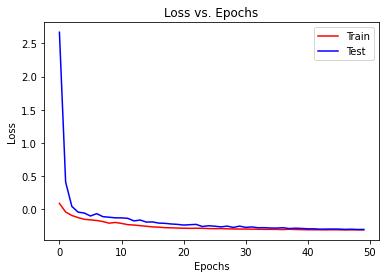

In [10]:
plt.plot(hist.history['loss'], color='red', label='Train')
plt.plot(hist.history['val_loss'], color='blue', label='Test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc="upper right")
plt.title('Loss vs. Epochs')
plt.show()

In [20]:
checkpoint_path = "./check_points/brain_0809_2cp.ckpt"
model.save_weights(checkpoint_path)

In [10]:
checkpoint_path = "./check_points/brain_0809_1cp.ckpt"
model.load_weights(checkpoint_path)


Two checkpoint references resolved to different objects (<tensorflow.python.keras.layers.convolutional.Conv3DTranspose object at 0x7f8c887aea90> and <tensorflow.python.keras.layers.convolutional.Conv3D object at 0x7f8c8875b320>).

Two checkpoint references resolved to different objects (<tensorflow.python.keras.layers.convolutional.Conv3D object at 0x7f8c8875b320> and <tensorflow.python.keras.layers.convolutional.Conv3D object at 0x7f8c8877a630>).

Two checkpoint references resolved to different objects (<tensorflow.python.keras.layers.convolutional.Conv3D object at 0x7f8c8877a630> and <tensorflow.python.keras.layers.convolutional.Conv3D object at 0x7f8c8876b748>).

Two checkpoint references resolved to different objects (<tensorflow.python.keras.layers.convolutional.Conv3DTranspose object at 0x7f8c887467b8> and <tensorflow.python.keras.layers.convolutional.Conv3D object at 0x7f8c8877acc0>).

Two checkpoint references resolved to different objects (<tensorflow.python.keras.layers.conv


Two checkpoint references resolved to different objects (<tensorflow.python.keras.layers.convolutional.Conv3D object at 0x7f8c88252e10> and <tensorflow.python.keras.layers.convolutional.Conv3D object at 0x7f8c8024f5f8>).

Two checkpoint references resolved to different objects (<tensorflow.python.keras.layers.convolutional.Conv3D object at 0x7f8c8826a470> and <tensorflow.python.keras.layers.convolutional.Conv3D object at 0x7f8c8836f550>).


ValueError: Shapes (3, 3, 3, 32, 32) and (1, 1, 1, 32, 32) are incompatible

In [21]:
## 간단하게 결과 보기 위한 코드 ##
output = model.predict(sample_loader)
moved = output['moved']
deformation = output['deformation']

In [22]:
# moved = moved * max_value
print(moved.shape)
a = moved[0]
b = deformation[0]

print(a.shape)
a = a.swapaxes(0,2) 
b = b.swapaxes(0,2) 
print(a.shape)

a = nib.Nifti1Image(a,None) 
b = nib.Nifti1Image(b,None)

nib.save(a,'IXI_/moved_2.nii.gz')
nib.save(b,'IXI_/deformation_2.nii.gz')

(3, 64, 128, 128, 1)
(64, 128, 128, 1)
(128, 128, 64, 1)


In [65]:
f1model = Model(inputs=model.model.input, outputs=model.model.get_layer('concat_3_rc').output)
pred2 = f1model.predict(sample_loader)

a = pred2[0]
print(a.shape)
a = a.swapaxes(0,2) 
print(a.shape)

a = nib.Nifti1Image(a,None) 

nib.save(a,'BTCV_Data/concat_3_rc.nii.gz')

(8, 16, 16, 64)
(16, 16, 8, 64)


In [54]:
filename = "./BTCV_Data/3affine/1.nii.gz"
deformation = pred2

gt_moving = nib.load(filename).get_fdata()
gt_moving = gt_moving.swapaxes(0,2)
gt_moving = tf.expand_dims(gt_moving, axis=0)
gt_moving = tf.expand_dims(gt_moving, axis=4)
print(gt_moving.shape)

nb, nd, nh, nw, nc = tf.shape(deformation)

# Regular grid.
grid = regular_grid_3d(nd, nh, nw)

grid = tf.expand_dims(grid, axis=0) 
multiples = tf.stack([nb, 1, 1, 1, 1])
grid = tf.tile(grid, multiples)

print(deformation[0].shape)
grid_new = grid + deformation[0]
grid_new = tf.clip_by_value(grid_new, -1, 1)

gt_moving = tf.cast(gt_moving, tf.float32)

gt = grid_sample_3d(gt_moving, grid_new, name='gt')
print(gt.shape)
gt = gt[0].numpy()
gt = gt.squeeze()
print(gt.shape)
gt = gt.swapaxes(0,2)
x = nib.Nifti1Image(gt, None) 
nib.save(x,'./BTCV_Data/moved결과1.nii.gz')

(1, 64, 128, 128, 1)
(64, 128, 128, 3)
(3, 64, 128, 128, 1)
(64, 128, 128)


In [11]:
def dice_coef(y_true, y_pred_bin):
                    
    intersection = 2.0 * np.sum(y_true * y_pred_bin)
    union = (np.sum(y_true) + np.sum(y_pred_bin))
    return (intersection / union)

In [17]:
filename = "./chaos_train_voxel/gtaffine.nii.gz"

rgt = nib.load(filename).get_fdata()
rgt = rgt.swapaxes(0,2)

mov = np.squeeze(moved[0])

print(dice_coef(mov, rgt))

0.2385860440177458


In [21]:
-gt_moved = gt_moved.swapaxes(0,2)

c = nib.Nifti1Image(gt_moved, None)
nib.save(c,'0530 결과/gt0530_04.nii.gz')

In [36]:
# Voxel Affine 저장 ###########
output = model.predict(sample_loader)
moved = output['moved']
moved = moved * (max_value - min_value) + min_value

a = 1
j = 0
for i in range (0, 39):
    filename = "./BTCV_Data/gt_resize/" + str(a) + ".nii.gz"
    if os.path.isfile(filename):
        
        x = moved[j]
        x = np.squeeze(x)
        x = x.swapaxes(0,2) 
        print(a, ":", x.shape )
        savename = "./BTCV_Data/6.최종결과_resize10/" + str(a) + ".nii.gz"
        x = nib.Nifti1Image(x, None) 
        nib.save(x,savename)
        
        j += 1
        
    a += 1

1 : (128, 128, 64, 3)
2 : (128, 128, 64, 3)
3 : (128, 128, 64, 3)


IndexError: index 3 is out of bounds for axis 0 with size 3